# MAE-HID SSL Ablation Visualization

HID counterpart to `consolidated_visualization.ipynb` (the HAR notebook). Same overall structure
(A0/A mask ratio, B/D mask strategy, C/E patch size, each at enc6/enc12) and the same
`load_matching_results` / completeness-diagnostic / best-layer-per-group machinery, adapted for
two things that are genuinely different about HID rather than assumed identical to HAR:

1. **`task_prefix="mae_hid"`** instead of `"mae_har"` (confirmed from your file audit: HID runs
   live under `mae_hid/`, `exp` names start with `mae_hid_`, and -- unlike HAR's `ep300` -- your HID
   runs are `ep150`. The loader filters by `exp` prefix, not epoch count, so this difference
   doesn't need special-casing, just noting.)
2. **Unknown metric schema.** HAR's `evals` entries have `knn_acc`/`lp_acc`/`knn_f1`/`lp_f1`, and
   because they're all "accuracy-like" it was valid to take a max across them to find a "best
   protocol". HID's real metrics are unconfirmed here -- per project notes they likely include
   things like closed-set accuracy, open-set Rank-1, and Verification AUC, which are **not on the
   same scale and must not be maxed against each other** (an AUC of 0.75 is not "worse" than a
   Rank-1 of 99% -- they're different measurements). So **Step 0 below inspects one real file and
   prints exactly what metric keys exist** before anything downstream assumes a name, and every
   "best layer" table here is built **per individual metric**, never by comparing across metrics.

**Also worth carrying over from project notes:** `test_cross_user` may be a degenerate single-identity
split for HID (Rank-1 trivially 100%, Verification AUC undefined/NaN because there are no negative
pairs). If Step 0 or the completeness check below flags `test_cross_user` as "missing" a metric,
that may be this expected degeneracy rather than a corrupted file -- the completeness cell notes
this explicitly rather than treating it as an error.

Edit `RESULTS_DIR` / `FIG_DIR` below before running.


In [2]:

import json
import re
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

# -- Paths ----------------------------------------------------------------
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")  # parent dir (same as HAR notebook)
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User (possibly degenerate for HID -- see notes)",
}


In [3]:

def load_matching_results(directory, filters, debug=False, task_prefix="mae_hid"):
    # Recursively load all *.json result files under `directory` whose `args` dict matches
    # every key/value in `filters`. task_prefix guards against other tasks (e.g. mae_har)
    # being picked up just because RESULTS_DIR is a shared parent directory -- see the HAR
    # notebook's file-audit discussion for why this matters.
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        exp_name = data.get("exp", "")
        if task_prefix is not None and not exp_name.startswith(task_prefix):
            if debug:
                print(f"[skip] {fp.name}: exp={exp_name!r} does not start with "
                      f"task_prefix={task_prefix!r}")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int) and not isinstance(expected, bool):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def group_by(results, key_fn):
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts


## Step 0 -- Inspect one real HID file's metric schema (do this before anything else)

Loads a single HID file with the loosest possible filter (just `task_prefix`) and prints exactly
what metric keys exist in `evals[checkpoint][layer][split]`, for every split separately (since
`test_cross_user` may legitimately have a different key set than the others if it's the degenerate
single-identity case). **Read this output before trusting any cell below** -- it tells you what to
put in `PRIMARY_METRICS` in the next cell.


In [4]:

SCHEMA_PROBE_FILTERS = {}  # no constraints -- just grab any mae_hid file to inspect
_probe_results = load_matching_results(RESULTS_DIR, SCHEMA_PROBE_FILTERS, debug=False, task_prefix="mae_hid")

if not _probe_results:
    print("No mae_hid files found at all under RESULTS_DIR -- check the path before continuing.")
else:
    _probe = _probe_results[0]
    print(f"Inspecting: {_probe.get('exp', '?')}")
    _ckpt = get_checkpoints(_probe)[-1]
    _layer = get_layers(_probe)[0]
    print(f"(checkpoint={_ckpt}, layer={_layer})\n")
    for split in TEST_SPLITS:
        entry = _probe["evals"].get(_ckpt, {}).get(_layer, {}).get(split)
        if entry is None:
            print(f"{split:<20} -- split not present at all")
            continue
        print(f"{split:<20} keys: {sorted(entry.keys())}")
        print(f"{'':<20} values: {entry}")
    print(f"\nAll top-level args for this run: {_probe.get('args')}")


Inspecting: mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
(checkpoint=epoch_150, layer=layer_1)

test_id              keys: ['centroid_cos_sim', 'centroid_l2_dist', 'knn_acc', 'knn_f1', 'lp_acc', 'lp_f1', 'mlp_acc', 'mlp_f1']
                     values: {'knn_acc': 0.9995654225349426, 'knn_f1': 0.9995656552525809, 'lp_acc': 0.9128639698028564, 'lp_f1': 0.9121567549225885, 'mlp_acc': 1.0, 'mlp_f1': 1.0, 'centroid_l2_dist': 0.17437201738357544, 'centroid_cos_sim': 0.9989830851554871}
test_cross_device    keys: ['n_identities', 'openset', 'rank1_acc', 'rank1_n_query', 'verif_auc', 'verif_eer', 'verif_n_pairs']
                     values: {'openset': True, 'n_identities': 7, 'rank1_acc': 0.9962632343782437, 'rank1_n_query': 4817, 'verif_auc': 0.7642537241710716, 'verif_eer': 0.331385679961557, 'verif_n_pairs': 4581}
test_cross_env       keys: ['centroid_cos_sim', 'centroid_l2_dist', 'knn_acc', 'knn_f1', 'lp_acc', 'lp_f1', 'mlp_acc', 'mlp_f1']
                   

## Step 1 -- Set `PRIMARY_METRICS` based on what Step 0 printed

**Edit this list to match your real metric key names from Step 0's output** -- this placeholder
list is a guess based on project notes (closed-set accuracy, open-set Rank-1, Verification AUC),
not confirmed against a real file. Every metric listed here gets its own independent "best layer"
table/plot below (never mixed with another metric via max/argmax, since they're on different
scales and mean different things).


In [5]:

# TODO: replace with the exact keys Step 0 printed. Common HID candidates per project notes:
#   - closed-set accuracy (e.g. "closed_set_acc" or "lp_acc" if closed-set reuses the HAR-style
#     probe names) -- only meaningful on splits where all identities were seen in training
#   - open-set Rank-1 retrieval (e.g. "rank1_acc") -- known ceiling effect on test_cross_device
#   - Verification AUC (e.g. "verification_auc" or "auc") -- the metric that actually discriminates
#     configs when Rank-1 is saturated; expected to be NaN/missing on the degenerate test_cross_user
PRIMARY_METRICS = ["closed_set_acc", "rank1_acc", "verification_auc"]  # <<< EDIT THIS

# Whether higher is better for each metric (all the above are; flip to False for anything
# where lower is better, e.g. an equal-error-rate style metric).
METRIC_HIGHER_IS_BETTER = {m: True for m in PRIMARY_METRICS}


## Step 2 -- Completeness diagnostic (per metric, `test_cross_user` treated as possibly-degenerate)

Same idea as the HAR notebook's `diagnose_incomplete_runs`, but checks each metric in
`PRIMARY_METRICS` independently, and prints a distinct, softer note (not `[!]`) when the only thing
missing is on `test_cross_user` -- since that may be the expected open-set degeneracy rather than a
broken run.


In [6]:

def diagnose_incomplete_runs_hid(results, label="", metrics=PRIMARY_METRICS, splits=TEST_SPLITS):
    any_issue = False
    for r in results:
        exp = r.get("exp", "?")
        for ckpt in get_checkpoints(r):
            for layer in get_layers(r):
                for split in splits:
                    entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                    if entry is None:
                        print(f"[{label}] {exp}: MISSING split '{split}' entirely at {ckpt}/{layer}")
                        any_issue = True
                        continue
                    missing = [m for m in metrics if m not in entry]
                    if missing:
                        if split == "test_cross_user":
                            print(f"[{label}] {exp}: {ckpt}/{layer}/{split} missing {missing} "
                                  f"-- note: may be the expected open-set degenerate case, not an error")
                        else:
                            print(f"[{label}] {exp}: {ckpt}/{layer}/{split} missing metrics: {missing}")
                        any_issue = True
    if not any_issue:
        print(f"[{label}] all {len(results)} run(s) have all of {metrics} present on all splits.")


## Step 3 -- Best layer per metric, per group (generic, reused across all sections below)

Mirrors the HAR notebook's Section H, but computes best-layer **per individual metric** (never
mixing metrics via max), and averages across the group's seeds at the final checkpoint.


In [7]:

def best_layer_for_metric(runs, metric, splits=TEST_SPLITS, checkpoint=None,
                           min_layer=None, max_layer=None, higher_is_better=True):
    if not runs:
        return {}
    checkpoint = checkpoint or get_checkpoints(runs[0])[-1]
    layers = get_layers(runs[0])
    if min_layer is not None or max_layer is not None:
        def _layer_num(l):
            return int(l.replace("layer_", ""))
        layers = [l for l in layers
                  if (min_layer is None or _layer_num(l) >= min_layer)
                  and (max_layer is None or _layer_num(l) <= max_layer)]

    out = {}
    for split in splits:
        best = None
        for layer in layers:
            vals = []
            for r in runs:
                ckpts = get_checkpoints(r)
                ckpt = checkpoint if checkpoint in ckpts else ckpts[-1]
                entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                if entry is None:
                    continue
                v = entry.get(metric)
                if v is None:
                    continue
                vals.append(v)
            if not vals:
                continue
            mean_v = float(np.mean(vals))
            is_better = (best is None or
                         (mean_v > best["mean_val"] if higher_is_better else mean_v < best["mean_val"]))
            if is_better:
                best = {"layer": layer, "mean_val": mean_v, "std_val": float(np.std(vals)), "n_seeds": len(vals)}
        out[split] = best
    return out


def build_best_layer_table_hid(groups, axis_name, metric, group_label_fmt="{k}",
                                min_layer=None, max_layer=None):
    higher_is_better = METRIC_HIGHER_IS_BETTER.get(metric, True)
    rows = []
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        best = best_layer_for_metric(runs, metric, min_layer=min_layer, max_layer=max_layer,
                                      higher_is_better=higher_is_better)
        for split, b in best.items():
            if b is None:
                continue
            rows.append(dict(axis=axis_name, metric=metric, group_key=key,
                              group_label=group_label_fmt.format(k=key), split=split,
                              layer=b["layer"], mean_val=b["mean_val"], std_val=b["std_val"],
                              n_seeds=b["n_seeds"]))
    return pd.DataFrame(rows)


def plot_best_layer_by_metric(groups, axis_title, group_label_fmt="{k}", figname_prefix="hid"):
    # One figure per metric in PRIMARY_METRICS -- never combined, since they're not comparable.
    for metric in PRIMARY_METRICS:
        df = build_best_layer_table_hid(groups, axis_title, metric, group_label_fmt=group_label_fmt)
        if df.empty:
            print(f"[skip] no data for metric='{metric}' in '{axis_title}' "
                  f"(check PRIMARY_METRICS matches your real key names)")
            continue
        print(f"\n=== {axis_title} -- {metric} ===")
        with pd.option_context("display.max_rows", None, "display.width", 140):
            print(df[["group_label", "split", "layer", "mean_val", "std_val", "n_seeds"]].to_string(index=False))

        group_labels_ordered = list(dict.fromkeys(df.sort_values("group_key")["group_label"]))
        x = np.arange(len(group_labels_ordered))
        split_colors = {"test_id": "#9AA5B1", "test_cross_device": "#DD8452",
                         "test_cross_env": "#C44E52", "test_cross_user": "#55A868"}

        fig, ax = plt.subplots(figsize=(7.5, 5))
        for split in TEST_SPLITS:
            sub = df[df.split == split].set_index("group_label").reindex(group_labels_ordered)
            if sub["mean_val"].isna().all():
                continue
            ax.plot(x, sub["mean_val"], marker="o", label=SPLIT_LABELS.get(split, split),
                    color=split_colors.get(split))
            ax.fill_between(x, sub["mean_val"] - sub["std_val"], sub["mean_val"] + sub["std_val"],
                             color=split_colors.get(split), alpha=0.12)
            for xi, (_, row) in zip(x, sub.iterrows()):
                if pd.notna(row["mean_val"]):
                    ax.annotate(row["layer"].replace("layer_", "L"), (xi, row["mean_val"]),
                                textcoords="offset points", xytext=(0, -12), fontsize=6.5,
                                ha="center", color=split_colors.get(split), alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(group_labels_ordered, rotation=30)
        ax.set_ylabel(metric)
        ax.set_title(f"{axis_title}\nbest layer per split, metric={metric}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"{figname_prefix}_{axis_title.split(':')[0].strip()}_{metric}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


## Section A0 -- Mask ratio, enc6 Ablation (HID)

In [8]:

A0_FILTERS = {
    "mask_strategy": 'random',
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

a0_results = load_matching_results(RESULTS_DIR, A0_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not a0_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    a0_groups = {}
else:
    a0_groups = group_by(a0_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(a0_results)} files across {len(a0_groups)} groups: "
          f"{ {k: len(v) for k, v in a0_groups.items()} }")
    diagnose_incomplete_runs_hid(a0_results, "A0")


Found 1 files across 1 groups: {0.75: 1}
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_1
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_user' entirely at epoch_50/layer_1
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_3
[A0] mae_hid_ep

In [9]:

if a0_groups:
    plot_best_layer_by_metric(a0_groups, "A0: mask ratio, enc6", group_label_fmt="mask={k}", figname_prefix="hid")


[skip] no data for metric='closed_set_acc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='rank1_acc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='verification_auc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)


## Section A -- Mask ratio, enc12 Ablation (HID)

In [10]:

A_FILTERS = {
    "mask_strategy": 'random',
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

a_results = load_matching_results(RESULTS_DIR, A_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not a_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    a_groups = {}
else:
    a_groups = group_by(a_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(a_results)} files across {len(a_groups)} groups: "
          f"{ {k: len(v) for k, v in a_groups.items()} }")
    diagnose_incomplete_runs_hid(a_results, "A")


Found 14 files across 4 groups: {0.5: 4, 0.75: 4, 0.875: 2, 0.95: 4}
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_

[skip] no data for metric='closed_set_acc' in 'A: mask ratio, enc12' (check PRIMARY_METRICS matches your real key names)

=== A: mask ratio, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
   mask=0.5 test_cross_device layer_9  0.998062 0.000259        3
   mask=0.5   test_cross_user layer_1  1.000000 0.000000        3
  mask=0.75 test_cross_device layer_3  0.998287 0.000307        4
  mask=0.75   test_cross_user layer_1  1.000000 0.000000        4
 mask=0.875 test_cross_device layer_3  0.997924 0.000208        2
 mask=0.875   test_cross_user layer_1  1.000000 0.000000        2
  mask=0.95 test_cross_device layer_3  0.998132 0.000000        4
  mask=0.95   test_cross_user layer_1  1.000000 0.000000        4


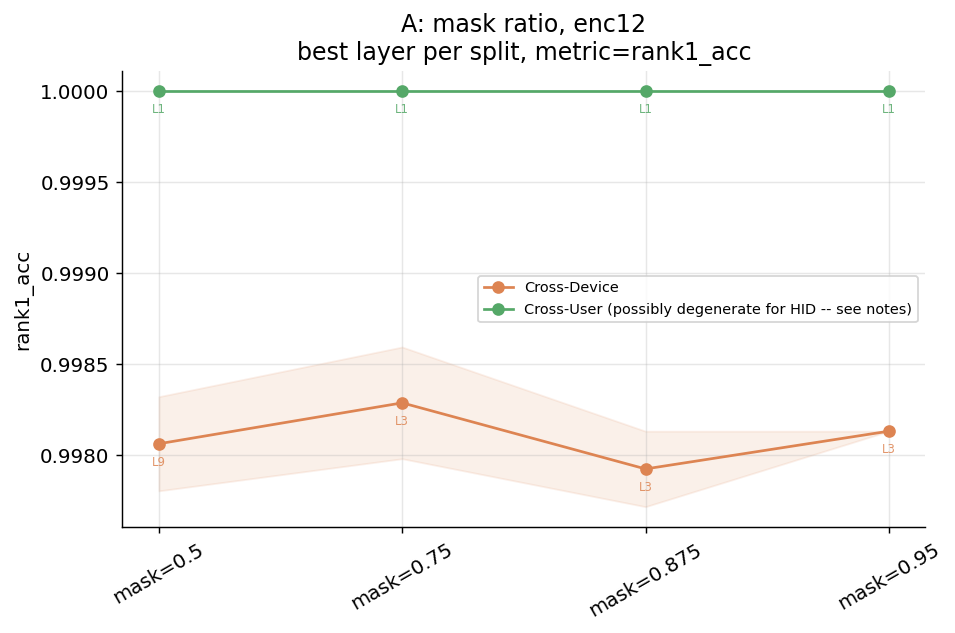

[skip] no data for metric='verification_auc' in 'A: mask ratio, enc12' (check PRIMARY_METRICS matches your real key names)


In [11]:

if a_groups:
    plot_best_layer_by_metric(a_groups, "A: mask ratio, enc12", group_label_fmt="mask={k}", figname_prefix="hid")


## Section B -- Mask strategy, enc6 Ablation (HID)

In [12]:

B_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

b_results = load_matching_results(RESULTS_DIR, B_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not b_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    b_groups = {}
else:
    b_groups = group_by(b_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(b_results)} files across {len(b_groups)} groups: "
          f"{ {k: len(v) for k, v in b_groups.items()} }")
    diagnose_incomplete_runs_hid(b_results, "B")


Found 1 files across 1 groups: {'random': 1}
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_1
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_user' entirely at epoch_50/layer_1
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_3
[B] mae_hid_ep300

In [13]:

if b_groups:
    plot_best_layer_by_metric(b_groups, "B: mask strategy, enc6", group_label_fmt="{k}", figname_prefix="hid")


[skip] no data for metric='closed_set_acc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='rank1_acc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='verification_auc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)


## Section D -- Mask strategy, enc12 Ablation (HID)

In [14]:

D_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

d_results = load_matching_results(RESULTS_DIR, D_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not d_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    d_groups = {}
else:
    d_groups = group_by(d_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(d_results)} files across {len(d_groups)} groups: "
          f"{ {k: len(v) for k, v in d_groups.items()} }")
    diagnose_incomplete_runs_hid(d_results, "D")


Found 12 files across 5 groups: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 4, 'time': 2}
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_e

[skip] no data for metric='closed_set_acc' in 'D: mask strategy, enc12' (check PRIMARY_METRICS matches your real key names)

=== D: mask strategy, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
         2d test_cross_device layer_6  0.998754 0.000415        2
         2d   test_cross_user layer_1  1.000000 0.000000        2
       freq test_cross_device layer_3  0.996263 0.000415        2
       freq   test_cross_user layer_1  1.000000 0.000000        2
      mixed test_cross_device layer_9  0.997924 0.000208        2
      mixed   test_cross_user layer_1  1.000000 0.000000        2
     random test_cross_device layer_3  0.998287 0.000307        4
     random   test_cross_user layer_1  1.000000 0.000000        4
       time test_cross_device layer_9  0.998235 0.000104        2
       time   test_cross_user layer_1  1.000000 0.000000        2


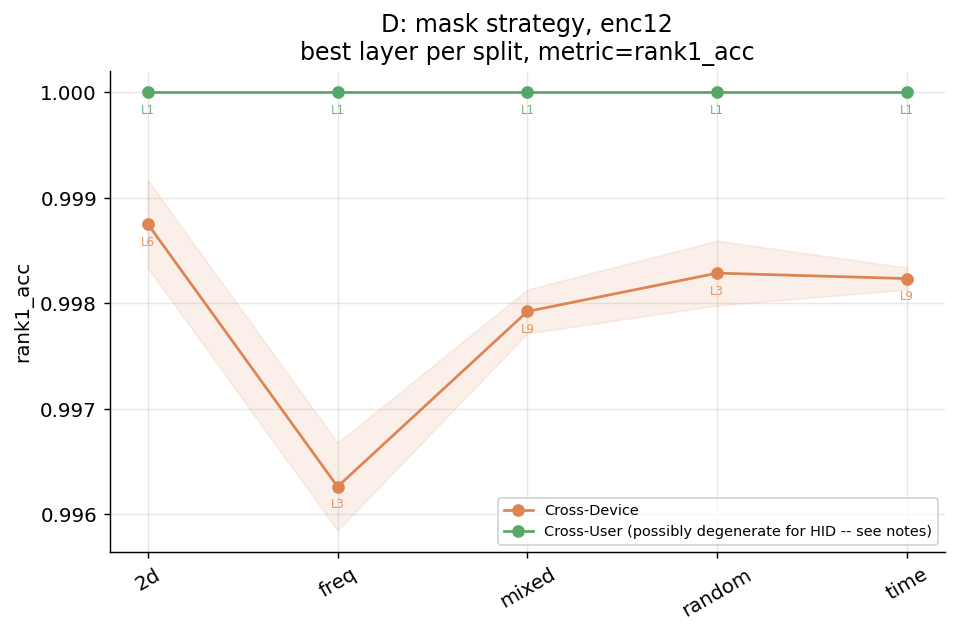

[skip] no data for metric='verification_auc' in 'D: mask strategy, enc12' (check PRIMARY_METRICS matches your real key names)


In [15]:

if d_groups:
    plot_best_layer_by_metric(d_groups, "D: mask strategy, enc12", group_label_fmt="{k}", figname_prefix="hid")


## Section C -- Patch size, enc6 Ablation (HID)

In [16]:

C_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "mask_strategy": 'random',
}

c_results_all = load_matching_results(RESULTS_DIR, C_FILTERS, debug=DEBUG, task_prefix="mae_hid")
c_results = [r for r in c_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not c_results:
    print("No matching square-patch HID files. Set DEBUG=True above and re-run.")
    c_groups = {}
else:
    c_groups = group_by(c_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(c_results)} files across {len(c_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in c_groups.items()} }")
    diagnose_incomplete_runs_hid(c_results, "C")


No matching square-patch HID files. Set DEBUG=True above and re-run.


In [17]:

if c_groups:
    plot_best_layer_by_metric(c_groups, "C: patch size, enc6", group_label_fmt="{k}x{k}", figname_prefix="hid")


## Section E -- Patch size, enc12 Ablation (HID)

In [18]:

E_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "mask_strategy": 'random',
}

e_results_all = load_matching_results(RESULTS_DIR, E_FILTERS, debug=DEBUG, task_prefix="mae_hid")
e_results = [r for r in e_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not e_results:
    print("No matching square-patch HID files. Set DEBUG=True above and re-run.")
    e_groups = {}
else:
    e_groups = group_by(e_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(e_results)} files across {len(e_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in e_groups.items()} }")
    diagnose_incomplete_runs_hid(e_results, "E")


Found 10 files across 5 patch sizes: {13: 2, 15: 2, 17: 2, 19: 2, 21: 2}
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_h

[skip] no data for metric='closed_set_acc' in 'E: patch size, enc12' (check PRIMARY_METRICS matches your real key names)

=== E: patch size, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
      13x13 test_cross_device layer_9  0.998754 0.000208        2
      13x13   test_cross_user layer_1  1.000000 0.000000        2
      15x15 test_cross_device layer_9  0.998858 0.000311        2
      15x15   test_cross_user layer_1  1.000000 0.000000        2
      17x17 test_cross_device layer_6  0.998132 0.000830        2
      17x17   test_cross_user layer_1  1.000000 0.000000        2
      19x19 test_cross_device layer_6  0.998339 0.000000        2
      19x19   test_cross_user layer_1  1.000000 0.000000        2
      21x21 test_cross_device layer_3  0.998028 0.000104        2
      21x21   test_cross_user layer_1  1.000000 0.000000        2


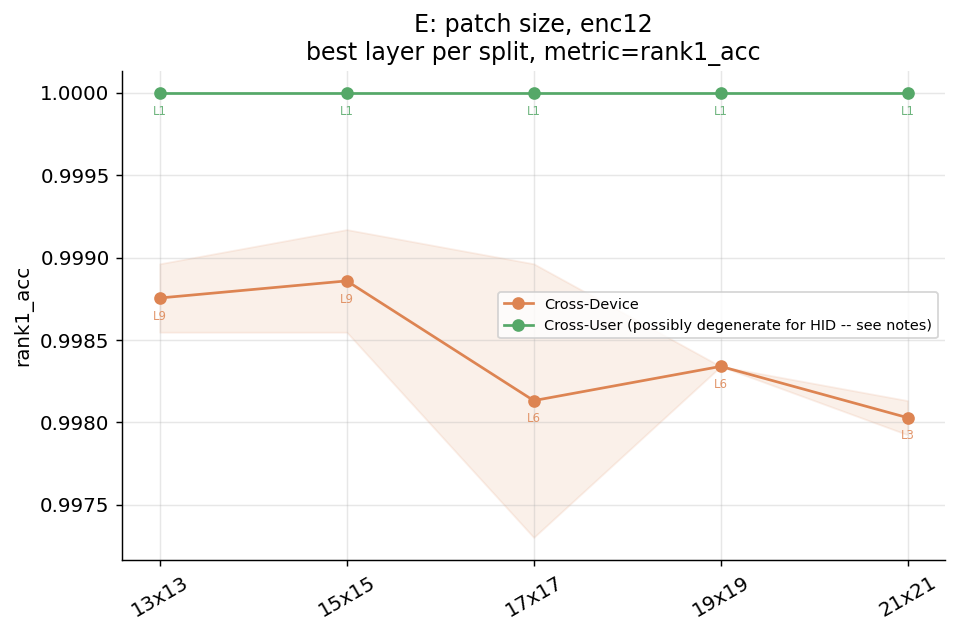

[skip] no data for metric='verification_auc' in 'E: patch size, enc12' (check PRIMARY_METRICS matches your real key names)


In [19]:

if e_groups:
    plot_best_layer_by_metric(e_groups, "E: patch size, enc12", group_label_fmt="{k}x{k}", figname_prefix="hid")


## Notes / caveats (HID-specific)

- **`PRIMARY_METRICS` in Step 1 is a placeholder guess** -- the whole notebook downstream depends
  on it matching your real metric key names from Step 0's schema probe. If every section above
  prints "no data for metric=..." for all your metrics, this is almost certainly why: go back to
  Step 0's output and fix the list.
- **`test_cross_user` may be degenerate** (single held-out identity) per project notes: Rank-1
  trivially 100%, Verification AUC undefined (no negative pairs to compute AUC from). Don't treat
  a missing/NaN value there as a data-quality bug without checking this first.
- **Never max/argmax across different metrics** (e.g. never compare a Rank-1 percentage against a
  Verification AUC to decide which is "better") -- this notebook's `best_layer_for_metric` avoids
  that by construction (one metric per call), but if you extend this notebook, keep that separation.
- Same `n` caveat as the HAR notebook: check `n_seeds` in the printed tables before trusting a
  result -- `n=1` where you expect 2 (missing seed) or an unexpected number (filter picking up an
  unintended file) both warrant a second look.
